In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
import pprint

In [2]:
res = pd.read_json("../logs/sharechat/sharechat_baseline_gemini-3-pro-preview_run_1.json")

In [3]:
pprint.pprint(res.iloc[1]['sampler_response'])

('Yes, it is a well-documented observation among political scientists and '
 'historians that autocratic leaders frequently offer simple solutions to '
 'complex problems. By reducing complicated socioeconomic issues into binary '
 "terms or scapegoating specific groups, they appeal to the public's "
 'psychological desire for certainty, security, and quick fixes during times '
 'of crisis. This rhetorical strategy helps them consolidate power by '
 'positioning themselves as the sole strongman capable of cutting through the '
 'slow, deliberative processes of democratic governance. Ultimately, however, '
 'these oversimplified policies rarely address the root causes of the issues '
 'and can lead to severe unintended consequences.')


In [4]:
res['sampler_search_calls'].describe()

count    77.000000
mean      0.922078
std       2.119870
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max      14.000000
Name: sampler_search_calls, dtype: float64

In [5]:
confidence_df = pd.read_csv("../results/sharechat/atomic_fact_confidence.csv")
confidence_df

,model,problem,has_search,search_calls,atomic_fact,attributed_to_search,reasoning,sampler_response,paraphrased_question,sample_1,sample_2,sample_3,sample_4,sample_5,num_clusters,cluster_sizes,entropy
0,gemini-3-pro-preview,Is resetting cmos and flashing the bios the same?,False,0,Resetting the CMOS and flashing the BIOS are d...,False,No search results available for this query.,"No, resetting the CMOS and flashing the BIOS a...",Are resetting the CMOS and flashing the BIOS t...,No.,No.,No.,No.,No.,1,[5],0.0000
1,gemini-3-pro-preview,Is resetting cmos and flashing the bios the same?,False,0,Resetting the CMOS clears a small volatile mem...,False,No search results available for this query.,"No, resetting the CMOS and flashing the BIOS a...",Does resetting the CMOS clear the small volati...,Yes.,Yes.,Yes.,Yes.,Yes.,1,[5],0.0000
2,gemini-3-pro-preview,Is resetting cmos and flashing the bios the same?,False,0,The CMOS memory chip stores custom system sett...,False,No search results available for this query.,"No, resetting the CMOS and flashing the BIOS a...",What does the CMOS memory chip store?,"BIOS configuration settings, hardware informat...",System configuration settings (BIOS/UEFI setti...,"BIOS/UEFI configuration settings, system time,...","BIOS/UEFI configuration settings, system time,...","BIOS settings, hardware configuration, and sys...",1,[5],0.0000
3,gemini-3-pro-preview,Is resetting cmos and flashing the bios the same?,False,0,Boot order is a system setting stored in the C...,False,No search results available for this query.,"No, resetting the CMOS and flashing the BIOS a...",Where is the boot order setting stored in a co...,NVRAM (or CMOS),CMOS (or NVRAM),NVRAM (or CMOS),CMOS / NVRAM,NVRAM (or CMOS),1,[5],0.0000
4,gemini-3-pro-preview,Is resetting cmos and flashing the bios the same?,False,0,System time is stored in the CMOS.,False,No search results available for this query.,"No, resetting the CMOS and flashing the BIOS a...",Which hardware component stores the system tim...,Real-Time Clock (RTC),Real-Time Clock (RTC),Real-Time Clock (RTC) / CMOS,Real-Time Clock (RTC),Real-Time Clock (RTC),1,[5],0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,gemini-3-pro-preview,Why did crypto rebound recently?,True,2,Leading cryptocurrency assets have reached new...,False,While the search results mention Bitcoin reach...,The recent rebound in the cryptocurrency marke...,Have leading cryptocurrency assets reached new...,Yes.,Yes.,Yes.,Yes.,Yes.,1,[5],0.0000
1000,gemini-3-pro-preview,Has apple exposed apple intelligence features ...,True,2,Apple has exposed its on-device large language...,True,Multiple search results confirm that Apple int...,"Yes, Apple has exposed its on-device large lan...",Has Apple made its on-device large language mo...,Yes.,"Yes, through the iOS 18 SDK (Apple Intelligenc...",Yes.,"Yes, via iOS 18 APIs (Apple Intelligence) and ...","Yes, through Apple Intelligence APIs (in iOS 1...",1,[5],0.0000
1001,gemini-3-pro-preview,Has apple exposed apple intelligence features ...,True,2,Apple introduced the Foundation Models framework.,True,The search results explicitly state that Apple...,"Yes, Apple has exposed its on-device large lan...",Did Apple introduce the Foundation Models fram...,No.,"No, researchers at Stanford University introdu...",No.,No.,No.,1,[5],0.0000
1002,gemini-3-pro-preview,Has apple exposed apple intelligence features ...,True,2,The Foundation Models framework provides a Swi...,True,The search results explicitly state that the F...,"Yes, Apple has exposed its on-device large lan...",Does the Foundation Models framework provide a...,No.,No.,No.,No.,No.,1,[5],0.0000


In [6]:
confidence_df[confidence_df['has_search']].reset_index(drop=True)['attributed_to_search'].mean()

np.float64(0.6190476190476191)

In [7]:
confidence_df[~confidence_df['attributed_to_search']]['entropy'].describe()

count    796.000000
mean       0.082837
std        0.288232
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.921900
Name: entropy, dtype: float64

In [8]:
confidence_df[confidence_df['attributed_to_search']]['entropy'].describe()

count    208.000000
mean       0.122377
std        0.398926
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.321900
Name: entropy, dtype: float64

In [9]:
from scipy import stats

stats.ttest_ind(confidence_df[confidence_df['attributed_to_search']]['entropy'], confidence_df[~confidence_df['attributed_to_search']]['entropy'])

TtestResult(statistic=np.float64(1.615469359859057), pvalue=np.float64(0.10652389200227927), df=np.float64(1002.0))

<Axes: >

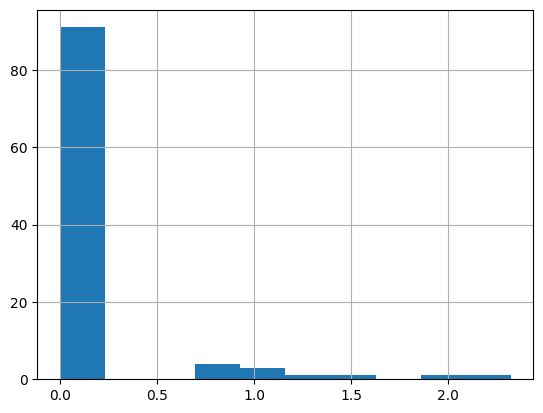

In [12]:
confidence_df[~confidence_df['attributed_to_search']]['entropy'].hist()

In [13]:
confidence_df[confidence_df['entropy'] > 0]

,model,problem,has_search,search_calls,atomic_fact,attributed_to_search,reasoning,sampler_response,paraphrased_question,sample_1,sample_2,sample_3,sample_4,sample_5,num_clusters,cluster_sizes,entropy
1,gemini-3-pro-preview,What was the population of the Nicosia neighbo...,True,1,The 2011 census recorded the population of Ayi...,True,The first search result explicitly states that...,"In the 2011 census, the Nicosia neighbourhood ...",What was the population of Ayios Loukas accord...,489,0,"1,010","1,020 (referring to Agios Loukas in Greece; if...",489,4,"[2, 1, 1, 1]",1.9219
2,gemini-3-pro-preview,What was the population of the Nicosia neighbo...,True,1,The namesake historic church of Ayios Loukas w...,False,None of the search results mention that the ch...,"In the 2011 census, the Nicosia neighbourhood ...",In what year was the historic church of Ayios ...,1986,1886,1986,1887,1758,4,"[2, 1, 1, 1]",1.9219
4,gemini-3-pro-preview,What was the population of the Nicosia neighbo...,True,1,The Dervish Pasha Mansion is located in North ...,False,The provided search results do not mention the...,"In the 2011 census, the Nicosia neighbourhood ...",Where is the Dervish Pasha Mansion located?,"Nicosia, Northern Cyprus.","North Nicosia, Northern Cyprus","Nicosia, Northern Cyprus","North Nicosia, Cyprus","Nicosia, Northern Cyprus",3,"[3, 1, 1]",1.3710
7,gemini-3-pro-preview,What was the population of the Nicosia neighbo...,True,1,Leontios died in 1947.,False,The search results do not mention a person nam...,"In the 2011 census, the Nicosia neighbourhood ...",In what year did Leontios die?,706 AD,705 AD,706,706,705,2,"[3, 2]",0.9710
8,gemini-3-pro-preview,What was the population of the Nicosia neighbo...,True,1,The funeral of Leontios took place in Nicosia.,False,The provided search results do not mention a p...,"In the 2011 census, the Nicosia neighbourhood ...",Where did the funeral of Leontios take place?,Monastery of Dalmatou (for Byzantine Emperor L...,Monastery of the Island of Prote,Monastery of Psamathion,Monastery of Psamathion,Monastery on the island of Prote,3,"[1, 2, 2]",1.5219
11,gemini-3-pro-preview,What is the name of the American Thoroughbred ...,True,1,Bolt d'Oro has no inbreeding through the first...,True,The first search result explicitly states that...,The American Thoroughbred racehorse you are re...,Does Bolt d'Oro have any inbreeding within the...,No.,No.,No.,Yes.,No.,2,"[4, 1]",0.7219
12,gemini-3-pro-preview,What is the name of the American Thoroughbred ...,True,1,Bolt d'Oro is a complete outcross.,False,The search results state that Bolt d'Oro has n...,The American Thoroughbred racehorse you are re...,Is Bolt d'Oro a complete outcross?,No.,No.,No.,No.,"Yes, Bolt d'Oro is considered a complete outcr...",2,"[4, 1]",0.7219
18,gemini-3-pro-preview,What is the name of the American Thoroughbred ...,True,1,The lawsuit sought to have Bolt d'Oro declared...,False,The provided search results focus on the pedig...,The American Thoroughbred racehorse you are re...,What did the lawsuit aim to achieve regarding ...,Disqualify Justify and redistribute the purse ...,To disqualify Justify and declare Bolt d'Oro t...,"To disqualify Justify, declare Bolt d'Oro the ...",To disqualify Justify and declare Bolt d'Oro t...,"To disqualify Justify, declare Bolt d'Oro the ...",2,"[4, 1]",0.7219
21,gemini-3-pro-preview,In which city was the person born on 1865-06-1...,True,1,Adriaan Schade van Westrum emigrated to the Un...,True,Search result [2] explicitly states that Adria...,Adriaan Schade van Westrum was born in Amsterd...,Did Adriaan Schade van Westrum emigrate to the...,Yes.,Yes.,Yes.,Yes.,"No, he emigrated to the United States in 1890.",2,"[4, 1]",0.7219
28,gemini-3-pro-preview,"In the music video for the song ""To Be or Not ...",False,0,"""To Be or Not to Be"" was released in 1983.",False,No search results available for this query.,"In the music video for the song ""To Be or Not ...","What year was ""To Be or Not to Be"" released?",1942